# 01 · Exploratory Data Analysis — job postings and advertised salary

**Goal of this notebook:** understand `jobs.duckdb` well enough to make four decisions that every later step depends on:

1. **What exactly is the target?** (which rows, which currency, which units, which transform)
2. **Which rows are trustworthy?** (unit mix-ups, outliers, duplicates)
3. **Where can the answer leak into the inputs?** (salary printed in the description)
4. **How should we split?** (reposts, company concentration, time)

The decisions are collected in the final section. Cleaning rules discovered here live in `salary_scout.cleaning` so the feature pipeline uses exactly the same logic.

Data: ~27k postings scraped from [hiring.cafe](https://hiring.cafe). See [`docs/jobs_data_dictionary.md`](../docs/jobs_data_dictionary.md) for column definitions.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

from salary_scout.data import load_jobs
from salary_scout.cleaning import (
    plausibility_mask, filter_plausible_compensation,
    strip_salary_mentions, strip_html,
    MIN_YEARLY, MAX_YEARLY, MAX_SPREAD_RATIO,
)

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

# Chart chrome: one hue for magnitude, fixed categorical order, recessive axes.
BLUE, ORANGE, AQUA, YELLOW, MAGENTA = "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"
SERIES = [BLUE, ORANGE, AQUA, YELLOW, MAGENTA]
plt.rcParams.update({
    "figure.dpi": 110, "figure.figsize": (9, 4),
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": "#52514e",
    "xtick.color": "#898781", "ytick.color": "#898781",
    "axes.grid": True, "grid.color": "#e1e0d9", "grid.linewidth": 0.8, "axes.axisbelow": True,
    "axes.titlelocation": "left", "axes.titleweight": "bold", "axes.titlesize": 11,
    "axes.prop_cycle": plt.cycler(color=SERIES),
})
usd_fmt = mtick.FuncFormatter(lambda v, _: f"${v/1000:.0f}k")

## 1. Load and overview

In [2]:
df = load_jobs()
print(f"{len(df):,} rows × {df.shape[1]} columns (deduplicated on requisition_id)")
df.head(3).T

27,098 rows × 46 columns (deduplicated on requisition_id)


,0,1,2
requisition_id,0btgmp1r0h9s5di1,0ln763glul01dp5d,0my0du94nxlmmxcq
id,grnhse___qcentrix___4693761005,workday___cigna-wd5-cignacareers___senior-advi...,zohorecruit___spektrasystems___627374000025844054
source,grnhse,workday,zohorecruit
board_token,qcentrix,cigna-wd5-cignacareers,spektrasystems
collapse_key,8b12285f966b9f90056a8432635ec730fa37ac50729c01...,e0e3f071f5602c614bdbbb66f8a033dd7629ba39971143...,a28d97a02d3a4412e7974685b4aa5b4c9053071630a14e...
title,Burn Registrar,Health Systems Strategy & Insights Senior Advisor,Software Development Engineer I (Full stack - ...
core_job_title,Burn Registrar,Health Systems Strategy & Insights,Software Development Engineer
job_category,Data and Analytics,Data and Analytics,Software Development
seniority_level,Senior Level,Senior Level,Entry Level
technical_tools,"[""MS Office"",""Electronic Medical Records (EMR)...","[""Artificial Intelligence"",""Copilot"",""Advanced...","[""C#"","".NET"",""REST"",""Microsoft SQL Server"",""jQ..."


In [3]:
null_share = df.isna().mean().sort_values(ascending=False)
null_share[null_share > 0].to_frame("null share").style.format("{:.1%}")

,null share
min_management_yoe,99.2%
stock_exchange,66.2%
latest_funding_type,60.1%
longitude,28.6%
latitude,28.6%
min_industry_and_role_yoe,18.6%
yearly_min_compensation,10.7%
yearly_max_compensation,10.7%
hourly_min_compensation,10.7%
hourly_max_compensation,10.7%


Most columns are complete. The notable gaps are `min_management_yoe` (essentially always empty, since every posting is an individual-contributor role), company funding/stock fields, and geocoordinates for roughly a quarter of postings (mostly remote roles). Compensation is missing for about 11% of rows.

## 2. The target: advertised compensation

### 2.1 Availability

`is_compensation_transparent` from the enrichment JSON is exactly the complement of "compensation is null". So there is no partial information to recover: a posting either has a parsed range or it doesn't.

In [4]:
pd.crosstab(df["is_compensation_transparent"], df["yearly_min_compensation"].isna().rename("comp missing"))

comp missing,False,True
is_compensation_transparent,,
False,0,2907
True,24191,0


Which postings publish pay? Transparency laws (California, New York, Colorado, Washington, and others) make this non-random. That matters for the model's scope: it learns the pricing behaviour of employers who *choose or are required to* disclose, and its predictions for other postings are an extrapolation.

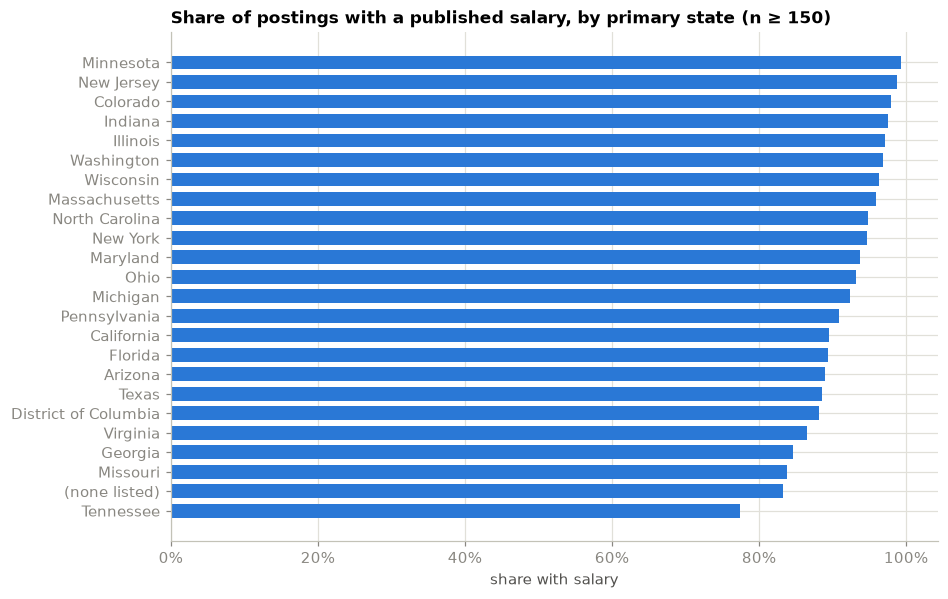

In [5]:
df["has_comp"] = df["yearly_min_compensation"].notna()
df["primary_state"] = (df["workplace_states"].fillna("[]").str.strip("[]").str.split(",").str[0]
                       .str.strip('"').str.replace(", US", "", regex=False).replace("", "(none listed)"))
by_state = (df.groupby("primary_state")["has_comp"].agg(["mean", "size"])
              .query("size >= 150").sort_values("mean"))
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(by_state.index, by_state["mean"], color=BLUE, height=0.7)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title("Share of postings with a published salary, by primary state (n ≥ 150)")
ax.set_xlabel("share with salary")
plt.show()

### 2.2 Currency

USD is 98% of postings with compensation. Version one of the model is USD-only; converting a few dozen CAD/EUR/GBP postings buys nothing and adds an exchange-rate assumption.

In [6]:
df["listed_compensation_currency"].replace("", "(empty)").value_counts().head(8).to_frame("postings")

,postings
listed_compensation_currency,
USD,26595
(empty),330
CAD,88
EUR,48
GBP,13
INR,9
MXN,4
PHP,3


### 2.3 Units and outliers

The raw ranges run from \$1 to \$340 million. Looking at the extremes alongside `listed_compensation_frequency` explains almost all of it:

- **Hourly rates stored as yearly.** `Yearly` postings with `min = 51.80, max = 60.69` are clearly per-hour figures the parser failed to annualise.
- **Yearly figures annualised again.** `Hourly` postings at \$223,479,360 are a yearly salary (~\$107k) multiplied by 2080 hours.
- **Genuine low values.** Part-time and contract annotation work at \$2–8/hour annualised to \$4k–17k. These are real, but they are a different labour market from the full-time salaried postings that dominate the data.

In [7]:
comp = df[df["has_comp"] & (df["listed_compensation_currency"] == "USD")].copy()
print(f"USD rows with compensation: {len(comp):,}")
comp[["yearly_min_compensation", "yearly_max_compensation"]].describe(
    percentiles=[.001, .01, .05, .25, .5, .75, .95, .99, .999]).T

USD rows with compensation: 24,037


,count,mean,std,min,0.1%,1%,5%,25%,50%,75%,95%,99%,99.9%,max
yearly_min_compensation,"24,037.00","214,376.56","4,486,386.21",1.00,48.84,"35,360.00","52,700.00","78,522.50","102,000.00","140,000.00","194,000.00","250,000.00","705,000.00","230,216,480.00"
yearly_max_compensation,"24,037.00","303,586.08","6,366,413.34",1.00,70.11,"41,600.00","70,000.00","110,730.00","149,600.00","196,200.00","280,000.00","385,000.00","1,125,715.24","340,496,000.00"


In [8]:
cols = ["title", "listed_compensation_frequency", "commitment", "yearly_min_compensation", "yearly_max_compensation"]
print("Lowest ranges:")
display(comp.nsmallest(8, "yearly_min_compensation")[cols])
print("Highest ranges:")
display(comp.nlargest(8, "yearly_max_compensation")[cols])

Lowest ranges:


,title,listed_compensation_frequency,commitment,yearly_min_compensation,yearly_max_compensation
2231,"Founding Design Engineer, AI Capability Develo...",Yearly,"[""Full Time""]",1.00,2.00
6533,"[C] Data Engineer, Safeguards",Yearly,"[""Full Time""]",1.00,2.00
7111,Contractor - Reporting,Yearly,"[""Full Time"",""Contract""]",1.00,1.00
7326,DataOps Engineer,Yearly,"[""Full Time""]",1.00,10.00
15412,Business Technology AI Engineer IV,Yearly,"[""Full Time""]",1.00,2.00
17096,Data Scientist,Yearly,"[""Full Time""]",1.00,2.00
21150,Front End Engineer,Yearly,"[""Full Time""]",1.00,2.00
22439,"Staff AI Engineer, Data Analytics & Modeling -...",Yearly,"[""Full Time""]",1.00,10.00


Highest ranges:


,title,listed_compensation_frequency,commitment,yearly_min_compensation,yearly_max_compensation
16341,Senior Data Analyst - Remote Nationwide,Hourly,"[""Full Time""]","190,736,000.00","340,496,000.00"
20460,Sr Software Engineer,Hourly,"[""Full Time""]","190,736,000.00","340,496,000.00"
3153,Software Development Engineer II,Hourly,"[""Full Time""]","206,930,880.00","327,032,160.00"
9733,Application Analyst III,Hourly,"[""Full Time""]","230,216,480.00","325,180,960.00"
33,Field Application Scientist,Hourly,"[""Full Time""]","223,479,360.00","316,160,000.00"
11072,"Data Scientist, ITA",Hourly,"[""Full Time""]","218,400,000.00","277,680,540.80"
13053,"Data Scientist, ITA",Hourly,"[""Full Time""]","218,400,000.00","277,680,540.80"
14178,"Data Scientist, ITA",Hourly,"[""Full Time""]","218,400,000.00","277,680,540.80"


Rather than try to repair these (which would mean guessing which direction each error went), we drop anything outside a plausible envelope and record what was dropped:

| rule | threshold | rationale |
|---|---|---|
| `min_ok` | yearly min ≥ \$20,000 | below US full-time minimum wage annualised; catches hourly-as-yearly |
| `max_ok` | yearly max ≤ \$1,000,000 | above the 99.9th percentile; catches yearly-as-hourly |
| `spread_ok` | max / min ≤ 3 | 99th percentile is 2.6; wider ranges are "\$10,000 – \$300,000" placeholders |
| `ordered` | min ≤ max | sanity |

These constants live in `salary_scout.cleaning`.

In [9]:
mask = plausibility_mask(df)
steps = ["has_comp", "is_usd", "min_ok", "max_ok", "spread_ok", "ordered"]
labels = ["has compensation", "+ USD", f"+ min ≥ ${MIN_YEARLY:,}", f"+ max ≤ ${MAX_YEARLY:,}",
          f"+ max/min ≤ {MAX_SPREAD_RATIO:g}", "+ min ≤ max"]
funnel = pd.Series({"all rows": len(df)} | {lab: mask[steps[:i+1]].all(axis=1).sum() for i, lab in enumerate(labels)})
funnel.to_frame("rows").assign(dropped=lambda t: (-t["rows"].diff().fillna(0)).astype(int))

,rows,dropped
all rows,27098,0
has compensation,24191,2907
+ USD,24037,154
"+ min ≥ $20,000",23927,110
"+ max ≤ $1,000,000",23902,25
+ max/min ≤ 3,23824,78
+ min ≤ max,23824,0


In [10]:
clean = filter_plausible_compensation(df)
clean["mid"] = (clean["yearly_min_compensation"] + clean["yearly_max_compensation"]) / 2
clean["spread_ratio"] = clean["yearly_max_compensation"] / clean["yearly_min_compensation"]
clean["log_mid"] = np.log(clean["mid"])
print(f"{len(clean):,} rows survive ({len(clean)/len(df):.1%} of all postings, {len(clean)/mask['has_comp'].sum():.1%} of postings with pay)")

23,824 rows survive (87.9% of all postings, 98.5% of postings with pay)


### 2.4 Distribution

Salary is right-skewed and multiplicative in nature (a 10% raise means more at \$200k than at \$60k), so we model it on a log scale. After the log transform the midpoint is close to symmetric.

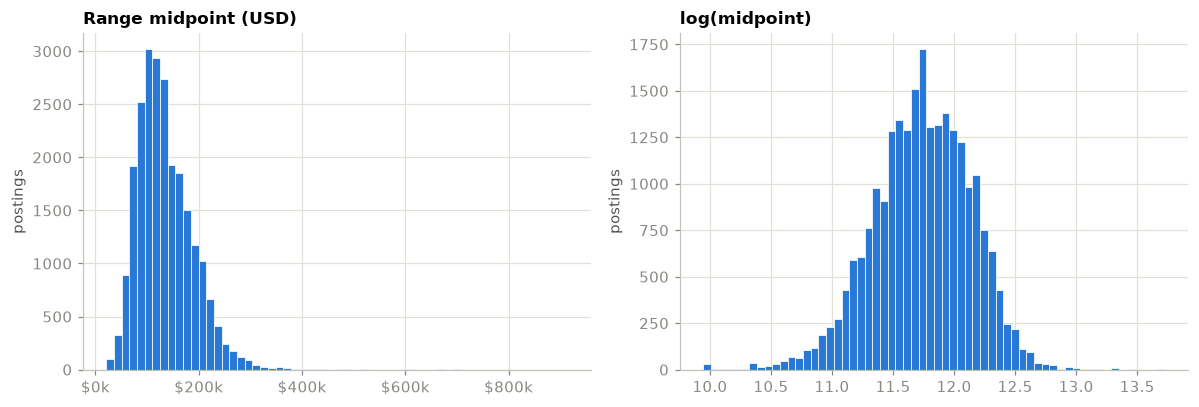

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].hist(clean["mid"], bins=60, color=BLUE, edgecolor="white", linewidth=0.5)
axes[0].xaxis.set_major_formatter(usd_fmt)
axes[0].set_title("Range midpoint (USD)")
axes[1].hist(clean["log_mid"], bins=60, color=BLUE, edgecolor="white", linewidth=0.5)
axes[1].set_title("log(midpoint)")
for ax in axes: ax.set_ylabel("postings")
plt.tight_layout(); plt.show()

The **range itself** is informative: the width is usually 20–60% of the minimum, and a few percent of postings advertise a single number. The spread ratio is only weakly related to the level, which supports predicting *level* and *width* as two separate quantities rather than min and max independently (independent predictions can produce max < min).

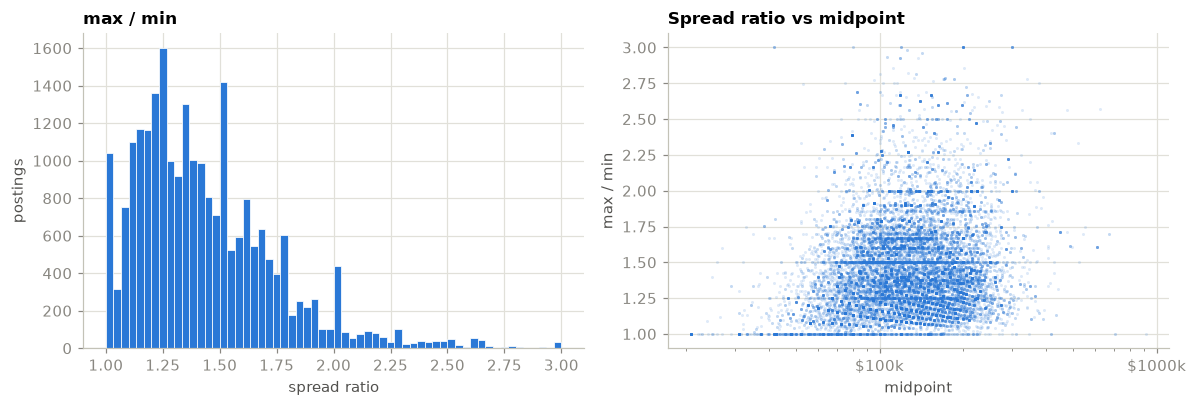

single-number ranges: 4.0%
corr(log mid, log spread) = 0.193


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].hist(clean["spread_ratio"], bins=60, color=BLUE, edgecolor="white", linewidth=0.5)
axes[0].set_title("max / min")
axes[0].set_xlabel("spread ratio"); axes[0].set_ylabel("postings")
axes[1].scatter(clean["mid"], clean["spread_ratio"], s=4, alpha=0.15, color=BLUE, linewidths=0)
axes[1].set_xscale("log"); axes[1].xaxis.set_major_formatter(usd_fmt)
axes[1].set_title("Spread ratio vs midpoint")
axes[1].set_xlabel("midpoint"); axes[1].set_ylabel("max / min")
plt.tight_layout(); plt.show()
print(f"single-number ranges: {(clean['spread_ratio'] == 1).mean():.1%}")
print(f"corr(log mid, log spread) = {np.corrcoef(clean['log_mid'], np.log(clean['spread_ratio']))[0,1]:.3f}")

## 3. Leakage: the answer is in the text

Pay-transparency postings usually print the range in the body. If we feed raw descriptions to a text model it will learn to read numbers, the reported accuracy will be meaningless, and a "description only" prediction mode would silently be a "copy the salary" mode.

In [13]:
def exact_figure_in_text(row, col):
    return f"{int(row['yearly_min_compensation']):,}" in row[col]

clean["desc_clean"] = clean["description"].map(strip_html).map(strip_salary_mentions)
clean["leaks_exact_min"] = clean.apply(exact_figure_in_text, axis=1, col="description")
clean["leaks_after_strip"] = clean.apply(exact_figure_in_text, axis=1, col="desc_clean")

print(f"exact min figure appears in raw description:          {clean['leaks_exact_min'].mean():.1%}")
print(f"exact min figure appears after strip_salary_mentions: {clean['leaks_after_strip'].mean():.2%}")

exact min figure appears in raw description:          67.0%
exact min figure appears after strip_salary_mentions: 0.00%


In [14]:
# What does the stripped text look like around a salary mention?
sample = clean[clean["leaks_exact_min"]].iloc[0]
i = sample["desc_clean"].find("[SALARY]")
print(sample["desc_clean"][max(0, i-300): i+200])

d organization. If you will be working at home occasionally or permanently, the internet connection must be obtained through a cable broadband or fiber optic internet service provider with speeds of at least 10Mbps download/5Mbps upload. For this position, we anticipate offering an annual salary of [SALARY]  USD / yearly, depending on relevant factors, including experience and geographic location. This role is also anticipated to be eligible to participate in an annual bonus plan. At The Cigna G


The regex-based scrubber removes the exact figure from essentially every posting. What remains is the *phrasing* around pay ("competitive base plus equity", "pay transparency statement", "hourly"), which is legitimate signal about the employer, not the answer itself. Residual leakage through non-comma numbers (`120000`) or spelled-out figures is checked again in the feature pipeline.

## 4. Duplication and grouping

`collapse_key` groups near-identical postings (the same role on several boards, in several locations, or reposted over time). Half of the collapse groups have more than one posting, and those groups cover almost 90% of postings. A random row-level split would put siblings of the same posting on both sides of the train/test boundary.

6,449 collapse groups for 23,824 postings
postings in a group of size ≥ 2: 86.8%


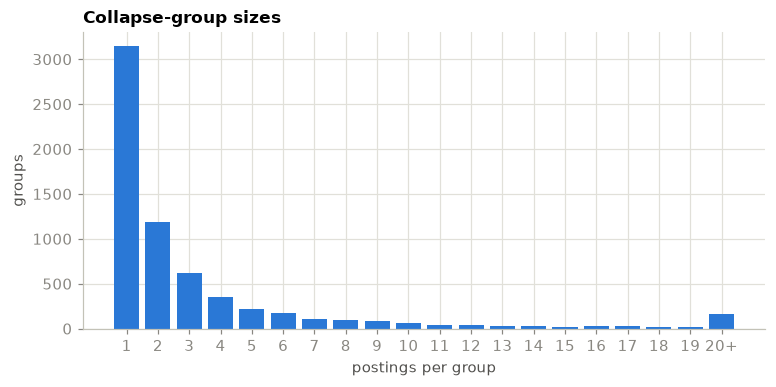

In [15]:
group_sizes = clean["collapse_key"].value_counts()
print(f"{clean['collapse_key'].nunique():,} collapse groups for {len(clean):,} postings")
print(f"postings in a group of size ≥ 2: {(clean['collapse_key'].map(group_sizes) >= 2).mean():.1%}")
fig, ax = plt.subplots(figsize=(8, 3.5))
sz = group_sizes.clip(upper=20).value_counts().sort_index()
ax.bar(sz.index, sz.values, color=BLUE, width=0.8)
ax.set_xticks(range(1, 21)); ax.set_xticklabels([str(i) if i < 20 else "20+" for i in range(1, 21)])
ax.set_title("Collapse-group sizes"); ax.set_xlabel("postings per group"); ax.set_ylabel("groups")
plt.show()

In [16]:
# Within a collapse group, is the salary identical? If so, these are true duplicates for our purposes.
grp = clean.groupby("collapse_key")["mid"].agg(["nunique", "size"]).query("size >= 2")
print(f"groups with ≥2 postings: {len(grp):,}; share where every posting has the same midpoint: {(grp['nunique'] == 1).mean():.1%}")

groups with ≥2 postings: 3,305; share where every posting has the same midpoint: 13.0%


Only about one multi-posting group in eight has an identical salary across all its members, so collapse groups are mostly *families* (the same role at different locations or levels) rather than exact copies. That makes them the right unit for splitting: siblings share a title, employer, and most of the description text, so a model that has seen one sibling has effectively seen the test row.

Company concentration is moderate: the largest employers (CVS, UnitedHealth, Humana, Google) contribute one to two hundred postings each out of nearly 7,000 employers. Grouping the split by `collapse_key` handles the duplication problem. We will *also* report a company-held-out score, because "predict pay for an employer you have never seen" is closer to what a user of the app is doing.

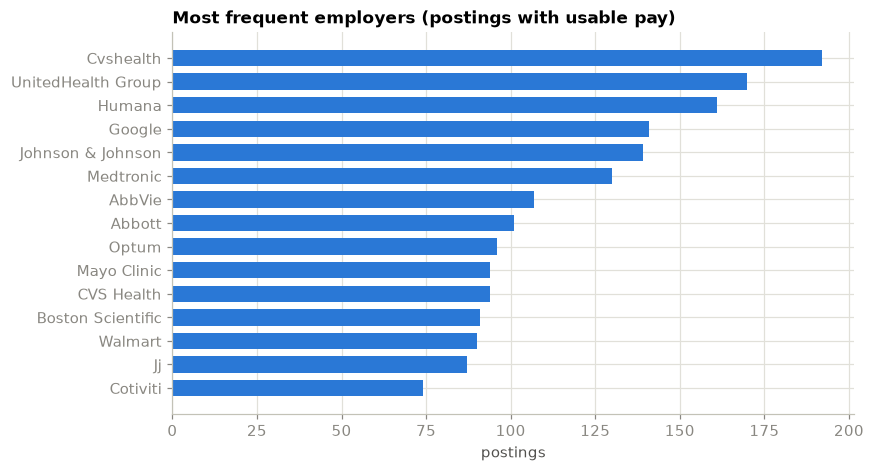

In [17]:
top = clean["company_name"].value_counts().head(15)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(top.index[::-1], top.values[::-1], color=BLUE, height=0.7)
ax.set_title("Most frequent employers (postings with usable pay)"); ax.set_xlabel("postings")
plt.show()

## 5. Time coverage

Almost all postings were published between April and September 2026. The long left tail is a few hundred older, still-live postings. This is effectively a **cross-sectional snapshot**, not a time series, so salary drift over time is not something this data can teach a model.

It does give a clean, honest protocol though: hold out the most recent postings as the final test set, which mimics "train on what has been posted, predict what gets posted next".

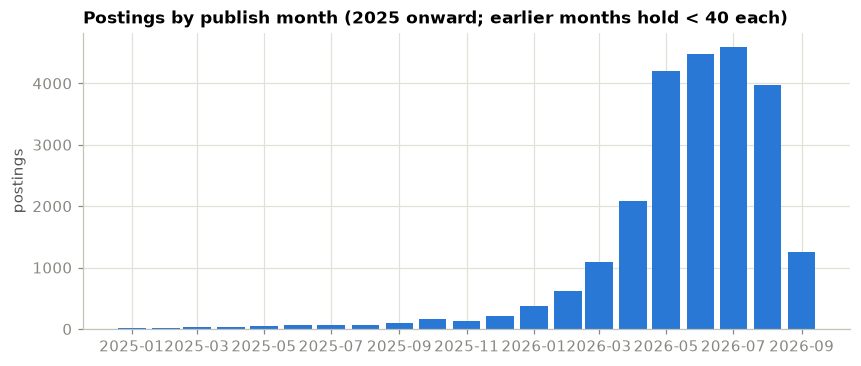

In [18]:
monthly = clean.set_index("publish_ts").resample("MS").size()
monthly = monthly[monthly.index >= "2025-01-01"]
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.bar(monthly.index, monthly.values, width=25, color=BLUE)
ax.set_title("Postings by publish month (2025 onward; earlier months hold < 40 each)")
ax.set_ylabel("postings")
plt.show()

## 6. Metadata vs salary

The point of these plots is to check that the cheap structured fields carry real signal, since "metadata only" must be a supported prediction mode.

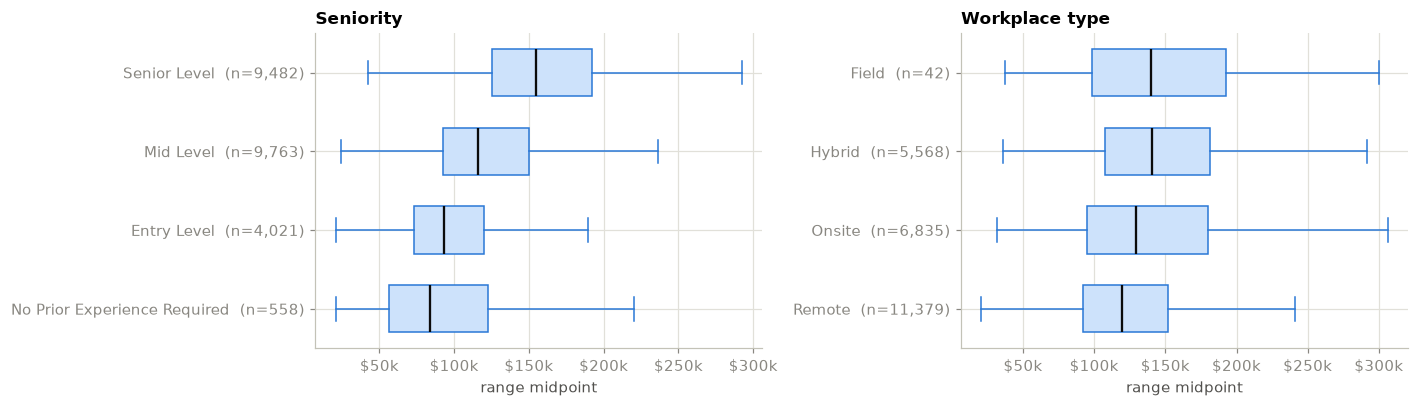

In [19]:
def box_by(col, order=None, title=None, ax=None, fmt=str):
    d = clean if order is None else clean[clean[col].isin(order)]
    order = order or d.groupby(col)["mid"].median().sort_values().index.tolist()
    data = [d.loc[d[col] == k, "mid"].values for k in order]
    ax = ax or plt.gca()
    ax.boxplot(data, orientation="horizontal", widths=0.6, showfliers=False, patch_artist=True,
               medianprops=dict(color="#0b0b0b", linewidth=1.5),
               boxprops=dict(facecolor="#cde2fb", edgecolor=BLUE),
               whiskerprops=dict(color=BLUE), capprops=dict(color=BLUE))
    ax.set_yticks(range(1, len(order) + 1))
    ax.set_yticklabels([f"{fmt(k)}  (n={len(v):,})" for k, v in zip(order, data)])
    ax.xaxis.set_major_formatter(usd_fmt); ax.set_xlabel("range midpoint")
    ax.set_title(title or col)
    return ax

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
box_by("seniority_level", ["No Prior Experience Required", "Entry Level", "Mid Level", "Senior Level"], "Seniority", axes[0])
box_by("workplace_type", ["Remote", "Onsite", "Hybrid", "Field"], "Workplace type", axes[1])
plt.tight_layout(); plt.show()

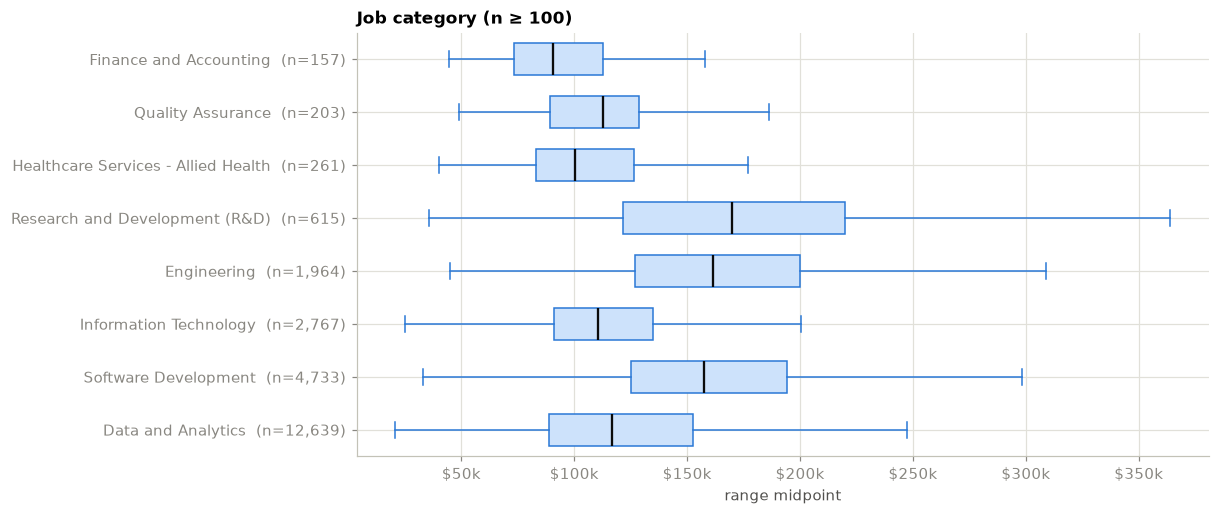

In [20]:
cats = clean["job_category"].value_counts()
cats = cats[cats >= 100].index.tolist()
fig, ax = plt.subplots(figsize=(10, 5))
box_by("job_category", cats, "Job category (n ≥ 100)", ax)
plt.show()

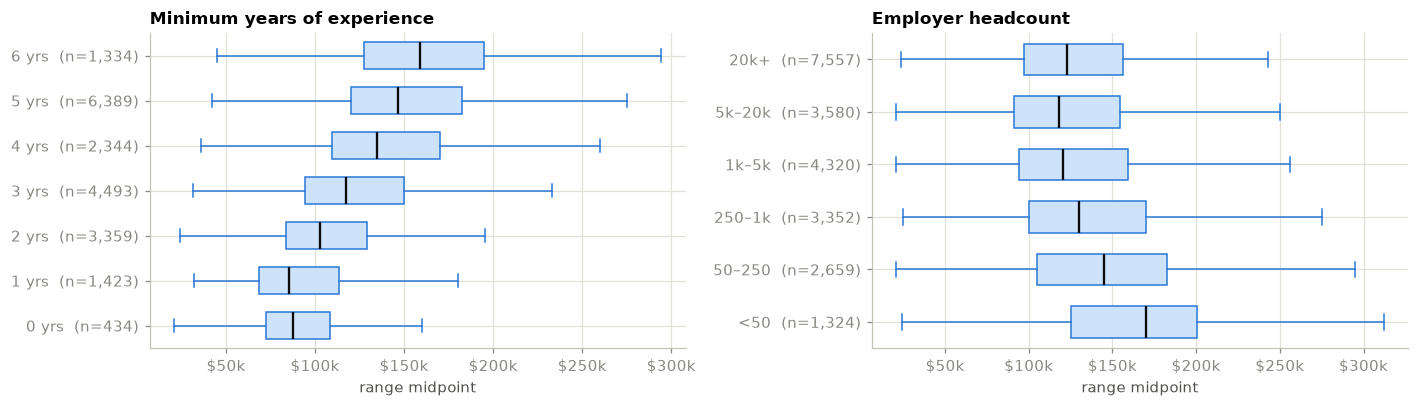

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
box_by("min_industry_and_role_yoe", [0, 1, 2, 3, 4, 5, 6], "Minimum years of experience", axes[0],
       fmt=lambda k: f"{int(k)} yrs")

# Company size: log-binned headcount
bins = [0, 50, 250, 1000, 5000, 20000, 1e9]
size_labels = ["<50", "50–250", "250–1k", "1k–5k", "5k–20k", "20k+"]
clean["size_bin"] = pd.cut(clean["nb_employees"], bins=bins, labels=size_labels)
box_by("size_bin", size_labels, "Employer headcount", axes[1])
plt.tight_layout(); plt.show()

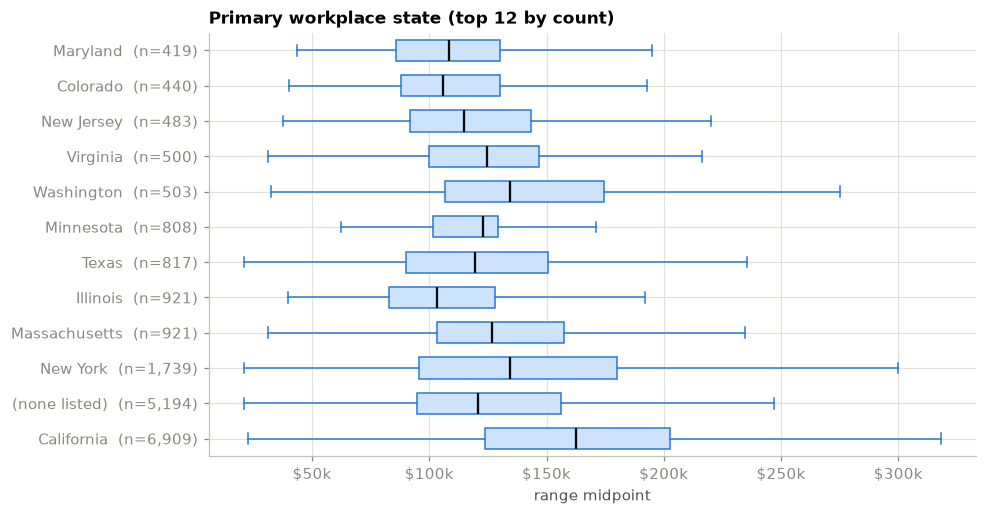

In [22]:
top_states = clean["primary_state"].value_counts().head(12).index.tolist()
fig, ax = plt.subplots(figsize=(9, 5))
box_by("primary_state", top_states, "Primary workplace state (top 12 by count)", ax)
plt.show()

Every structured field separates salary in the expected direction: seniority is the strongest single factor, followed by category (software and engineering above data/analytics and IT), years of experience, and employer size. Remote roles are paid a little *less* than hybrid ones, which is consistent with national rather than coastal-city pay bands. Location effects are visible but smaller than role effects once the category is fixed.

A quick sense of how much variance the metadata alone explains, using a plain one-hot linear model on log midpoint (no tuning, just a floor for the benchmark notebook):

In [23]:
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Ridge
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder

meta_cols = ["seniority_level", "job_category", "workplace_type", "primary_state", "size_bin", "source"]
X = clean[meta_cols].astype(str)
y = clean["log_mid"]
pipe = make_pipeline(
    ColumnTransformer([("oh", OneHotEncoder(handle_unknown="ignore", min_frequency=20), meta_cols)]),
    Ridge(alpha=1.0),
)
cv = GroupKFold(n_splits=5)
r2 = cross_val_score(pipe, X, y, groups=clean["collapse_key"], cv=cv, scoring="r2")
mae = -cross_val_score(pipe, X, y, groups=clean["collapse_key"], cv=cv, scoring="neg_mean_absolute_error")
print(f"metadata-only ridge, grouped 5-fold: R² = {r2.mean():.3f} ± {r2.std():.3f};  "
      f"MAE in log space = {mae.mean():.3f} (≈ {np.expm1(mae.mean()):.0%} typical error)")

metadata-only ridge, grouped 5-fold: R² = 0.484 ± 0.025;  MAE in log space = 0.222 (≈ 25% typical error)


## 7. The description text

Descriptions are HTML for 99% of postings, average ~9k characters, and a few are enormous (half a megabyte of boilerplate). Title and `core_job_title` are the highest-density text; `technical_tools` is an already-extracted skill list that makes a natural bag-of-tokens feature block.

,count,mean,std,min,5%,50%,95%,99%,max
chars after HTML strip,"23,824.00","6,307.78","3,335.33",14.00,"2,723.00","5,913.00","10,708.00","15,993.32","126,212.00"


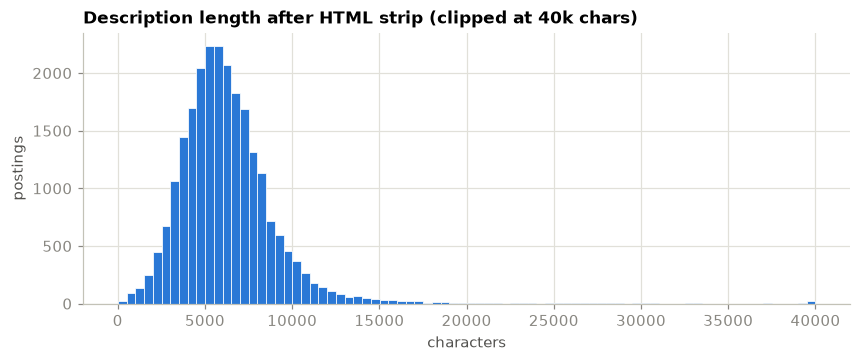

In [24]:
lens = clean["desc_clean"].str.len()
display(lens.describe(percentiles=[.05, .5, .95, .99]).to_frame("chars after HTML strip").T)
fig, ax = plt.subplots(figsize=(9, 3.2))
ax.hist(lens.clip(upper=40000), bins=80, color=BLUE, edgecolor="white", linewidth=0.5)
ax.set_title("Description length after HTML strip (clipped at 40k chars)"); ax.set_xlabel("characters"); ax.set_ylabel("postings")
plt.show()

19,060 distinct tools; median 7 per posting


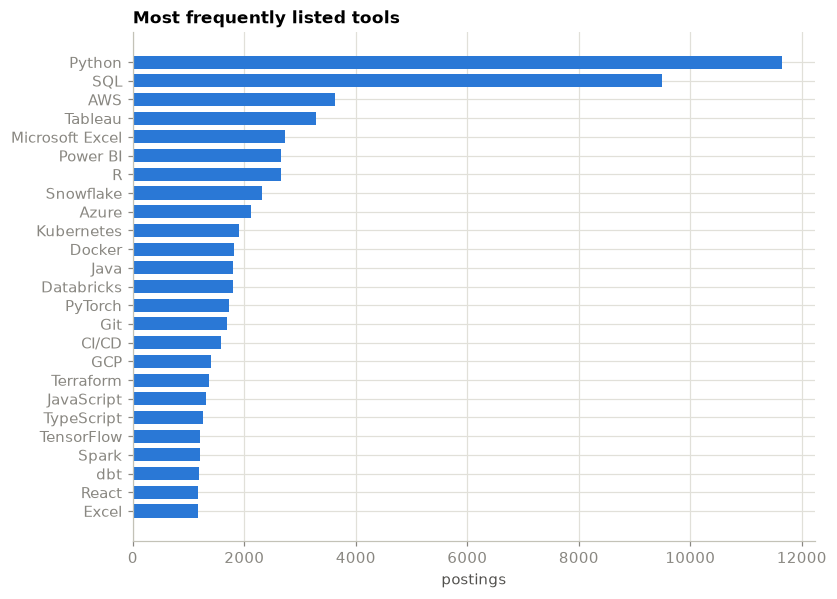

In [25]:
tools = clean["technical_tools"].dropna().map(json.loads)
tool_counts = pd.Series([t for lst in tools for t in lst]).value_counts()
print(f"{len(tool_counts):,} distinct tools; median {tools.map(len).median():.0f} per posting")
top_tools = tool_counts.head(25)
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top_tools.index[::-1], top_tools.values[::-1], color=BLUE, height=0.7)
ax.set_title("Most frequently listed tools"); ax.set_xlabel("postings")
plt.show()

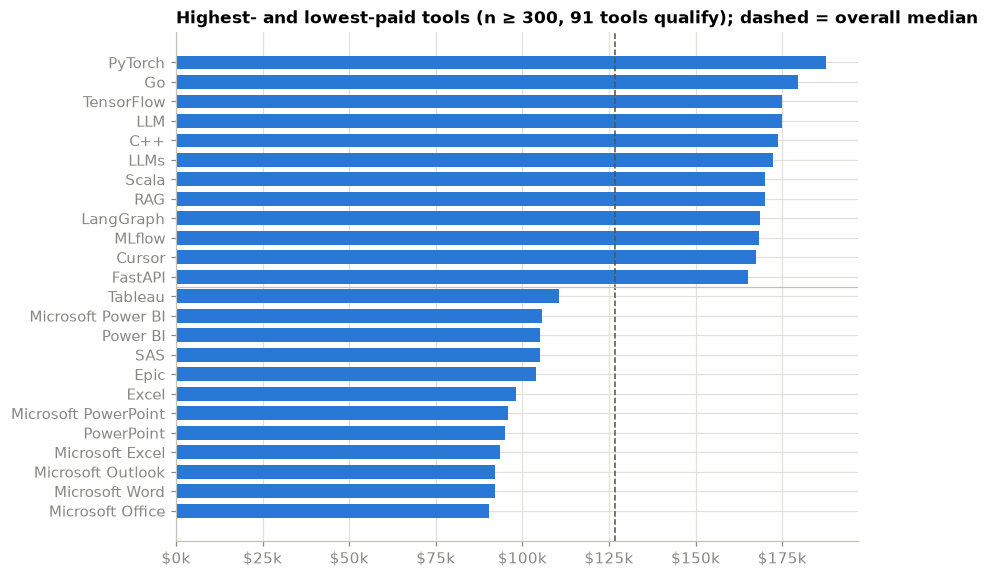

In [26]:
# Do specific tools move salary? Median midpoint for postings that mention each common tool.
exploded = clean[["mid"]].join(tools.rename("tool")).explode("tool")
tool_med = (exploded.groupby("tool")["mid"].agg(["median", "size"]).query("size >= 300")
            .sort_values("median"))
ends = pd.concat([tool_med.tail(12), tool_med.head(12)]).sort_values("median")
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(ends.index, ends["median"], color=BLUE, height=0.7)
ax.axvline(clean["mid"].median(), color="#52514e", linewidth=1, linestyle="--")
ax.axhline(11.5, color="#c3c2b7", linewidth=0.8)
ax.xaxis.set_major_formatter(usd_fmt)
ax.set_title(f"Highest- and lowest-paid tools (n ≥ 300, {len(tool_med)} tools qualify); dashed = overall median")
plt.show()

## 8. Decisions

**Target.** Two quantities in log space, derived from the cleaned USD range:

- `log_mid = log((min + max) / 2)` — the pay level
- `log_spread = log(max / min)` — the width of the advertised band, always ≥ 0

Min and max are reconstructed from these, which guarantees min ≤ max. Reported metrics: MAE and MAPE of the midpoint in dollars, plus the share of test postings whose true range overlaps the predicted range.

**Rows.** `filter_plausible_compensation`: has a parsed range, USD, min ≥ \$20k, max ≤ \$1M, max/min ≤ 3. This keeps about 23.8k of the 24.2k postings that publish pay.

**Leakage.** Descriptions are HTML-stripped and dollar figures replaced with a `[SALARY]` token before any text feature is built. Title, `core_job_title` and `requirements_summary` get the same treatment.

**Splits.** Grouped by `collapse_key` so reposts never straddle a boundary. Final test set: the most recent ~15% of postings by publish date. Model selection on grouped 5-fold cross-validation within the remaining data. A supplementary company-held-out evaluation quantifies how much the model relies on recognising the employer.

**Feature blocks** (each can be masked at prediction time):

| block | source columns |
|---|---|
| `title` | `title`, `core_job_title` |
| `description` | `description` (cleaned), `requirements_summary` |
| `role_meta` | `seniority_level`, `job_category`, `min_industry_and_role_yoe`, `commitment`, degree requirements, `security_clearance`, `technical_tools` |
| `location` | `workplace_type`, `primary_state`, `workplace_countries`, lat/lon |
| `company` | `company_name`, `nb_employees`, `year_founded`, `organization_type`, `company_industries`, `source` |

**Scope caveats to carry into the report.** The data is a 2026 snapshot of individual-contributor roles, heavily weighted toward data/analytics and software, from employers that publish pay. The model will be least reliable for management roles, non-US markets, and employers outside the transparency-law states.

**Baseline to beat.** Metadata-only ridge regression on six categorical fields already explains a meaningful share of log-salary variance (printed in §6). The benchmark notebook starts from there.